# Variance Risk Premium — S&P 500 Options
## Part 2 · Econometric Models

**Research question**: Does the implied volatility surface predict future realized volatility beyond what the return history alone provides?

| Section | Models | Question |
|---------|--------|----------|
| 2 · Historical benchmarks | Mean, HAR, EGARCH | What does the return history predict? |
| 3 · Implied volatility | Nested OLS, Mincer-Zarnowitz | What do option prices reveal? |
| 3B · VAR/VECM | Cointegration, Granger | Is the IV–RV relationship dynamic? |
| 4 · Panel | FE, RE, Hausman | Is the surface reducible to ATM IV? |
| 5 · PCA | Surface factors | How to exploit the full surface? |
| 6 · Hybrid | HAR-IV, HAR-PCA | Does IV add beyond historical information? |
| 7 · OOS evaluation | RMSE, QLIKE, DM | Which model wins out-of-sample? |
| 7B · Robustness | Volmageddon sensitivity | Are results driven by a single event? |
| 8 · Trading | VRP signal, Sharpe | Does accuracy translate to economic value? |


## 1 · Setup

In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq
import warnings, os, glob
from statsmodels.stats.diagnostic import acorr_breusch_godfrey, het_white
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm
from scipy import stats
import yfinance as yf 
import pickle

from utilities.ts_construction import extract_daily_metrics
from utilities.linear_regression import ols, reg_table
from utilities.fixed_random_effects import within_estimator, build_surface_panel


In [ ]:
# ── Load features from notebook 1 ────────────────────────────────────────────
with open('time_series.pkl', 'rb') as f:
    ts = pickle.load(f)
reg_overlap    = ts['reg_overlap']
reg_nonoverlap = ts['reg_nonoverlap']
metrics        = ts['metrics']
df             = ts['df']
spot_ts        = ts['spot_ts']
log_ret        = ts['log_ret']
rv_d_var       = ts['rv_d_var']   # r_t^2 x 252 - daily variance proxy (HAR components)

In [118]:
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans',
})

# ── User settings ──────────────────────────────────────────────────────────────
DATA_FOLDER   = './data'        # folder containing all YYYY-MM-DD.csv files
TARGET_TENOR  = 30              # target tenor in days for daily metrics
WING_LOW      = -0.15           # put-wing lower bound (log-moneyness)
WING_HIGH_PUT = -0.05           # put-wing upper bound
WING_LOW_CALL =  0.05           # call-wing lower bound
WING_HIGH     =  0.15           # call-wing upper bound
RV_WINDOW     = 21              # rolling window for realized vol (trading days)

print("Libraries loaded")

Libraries loaded


In [119]:
# ── Import VIX ─────────────────────────────────────────────────────────────────
vix = yf.Ticker("^VIX")
hist = vix.history(start="2017-06-09", end="2018-06-08")
Vix_close = hist["Close"]
Vix_close.index = Vix_close.index.tz_localize(None)

# ── Overlapping ────────────────────────────────────────────────────────────────
reg = reg_overlap.copy()
reg = reg.join(Vix_close.rename("vix"), how="left")
reg['vix_norm']       = reg['vix'] / 100
reg['vix_atm_spread'] = reg['vix_norm'] - reg['atm_iv']

# ── Non-overlapping ────────────────────────────────────────────────────────────
reg_no = reg_nonoverlap.copy()
reg_no = reg_no.join(Vix_close.rename("vix"), how="left")
reg_no['vix_norm']       = reg_no['vix'] / 100
reg_no['vix_atm_spread'] = reg_no['vix_norm'] - reg_no['atm_iv']

print(f"Overlapping    : N = {len(reg.dropna(subset=['vix']))}")
print(f"Non-overlapping: N = {len(reg_no.dropna(subset=['vix']))}")


Overlapping    : N = 211
Non-overlapping: N = 11


## 2 · Historical Benchmarks

These models use **only past return information** — no option data. 
They establish the baseline any IV model must beat to justify its complexity.

### 2.1 Historical Mean

$\widehat{RV}_{t+21} = \bar{RV}$ — the naïve floor. Any model failing to beat this is uninformative.

In [120]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox

y_full    = reg_overlap['rv_forward'].dropna()
hist_mean = y_full.mean()
print(f'Historical Mean : {hist_mean:.4f}')
print(f'RMSE : {np.sqrt(np.mean((y_full - hist_mean)**2)):.4f}')
print(f'MAE  : {np.mean(np.abs(y_full - hist_mean)):.4f}')

Historical Mean : 0.1166
RMSE : 0.0804
MAE  : 0.0660


### 2.2 HAR (Corsi, 2009)

$$\text{Var}^{\text{fwd}}_t = \beta_0 + \beta_d RV^d_t + \beta_w RV^w_t + \beta_m RV^m_t + \varepsilon_t$$

**Estimation space: variance.** Following Corsi (2009) and Andersen et al. (2003), the model is estimated
with realized variance as both target and regressors. The theoretical motivation is that variance
is additive across time horizons under standard no-arbitrage assumptions, making the HAR
cascade linear in expectation. Estimating in volatility would introduce a Jensen's inequality
bias in the coefficients.

The daily variance proxy is $RV^d_t = r_t^2 \times 252$ -- instantaneous, not a rolling window.
This is noisier than an intraday estimator, which limits the statistical power of the weekly
and monthly components on a daily dataset.

**Forecast conversion.** The model produces a variance forecast $\widehat{\text{Var}}^{\text{fwd}}_t$.
For evaluation and comparison with IV-based models (estimated in volatility space), this is
converted back to volatility: $\widehat{RV}^{\text{fwd}}_t = \sqrt{\max(\widehat{\text{Var}}^{\text{fwd}}_t, 0)}$.

F-test below checks whether HAR reduces to AR(1) on this dataset.

In [ ]:
# =============================================================================
# HAR-RV Benchmark (Corsi, 2009) - estimated in variance space
# Target : future realized variance over next 21 trading days
# Output : har_fitted_vol (annualized volatility) for forecast evaluation
# =============================================================================

from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. HAR components from pickle (rv_d_var = r_t^2 x 252)
df_har = pd.DataFrame({
    'rv_d': rv_d_var,
    'rv_w': rv_d_var.rolling(5).mean(),
    'rv_m': rv_d_var.rolling(21).mean(),
}, index=log_ret.index)

# 2. Target: future realized variance = rv_forward^2
df_har = df_har.join(reg_overlap[['rv_forward']], how='inner')
df_har['target_var'] = df_har['rv_forward'] ** 2
df_har = df_har.dropna()

print('=' * 70)
print('HAR DATASET')
print('=' * 70)
print(f'Observations : {len(df_har)}')
print(f'Period       : {df_har.index[0].date()} -> {df_har.index[-1].date()}')
print('\nDescriptive statistics')
print(df_har[['rv_d', 'rv_w', 'rv_m', 'target_var']].describe().round(4))

# 3. Estimate HAR in variance space
y_har = df_har['target_var']
X_har = sm.add_constant(df_har[['rv_d', 'rv_w', 'rv_m']])
har_model = sm.OLS(y_har, X_har).fit(cov_type='HAC', cov_kwds={'maxlags': 21})

# 4. Results
print('\n' + '=' * 70)
print('HAR-RV RESULTS  (variance space)')
print('=' * 70)
coef_table = pd.DataFrame({
    'coef'    : har_model.params,
    'std err' : har_model.bse,
    't-stat'  : har_model.tvalues,
    'p-value' : har_model.pvalues
}).round(4)
print(coef_table)
print(f'\nR2     : {har_model.rsquared:.4f}')
print(f'Adj R2 : {har_model.rsquared_adj:.4f}')
print(f'AIC    : {har_model.aic:.2f}  |  BIC : {har_model.bic:.2f}')
print(f'N obs  : {int(har_model.nobs)}')

# 5. HAR vs AR(1)
f_har_test = har_model.f_test('(rv_w = 0), (rv_m = 0)')
print('\n' + '=' * 70)
print('HAR vs AR(1)')
print('=' * 70)
print(f'F-statistic : {float(f_har_test.fvalue):.2f}')
print(f'p-value     : {float(f_har_test.pvalue):.4f}')

# 6. Residual diagnostics
lb = acorr_ljungbox(har_model.resid, lags=[5, 10, 21], return_df=True)
print('\n' + '=' * 70)
print('LJUNG-BOX TEST ON RESIDUALS')
print('=' * 70)
print(lb[['lb_stat', 'lb_pvalue']].round(4).to_string())

# 7. Store fitted values - convert variance forecast to volatility
df_har['har_fitted_var'] = har_model.fittedvalues
df_har['har_resid']      = har_model.resid
df_har['har_fitted_vol'] = np.sqrt(np.maximum(df_har['har_fitted_var'], 0))

# 8. Visualization (volatility space for readability)
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
ax = axes[0]
ax.plot(df_har.index, df_har['rv_d'], color='lightgray', lw=0.7, alpha=0.7, label='Daily variance proxy')
ax.plot(df_har.index, df_har['rv_w'], color='steelblue', lw=1.2, label='Weekly var (5d avg)')
ax.plot(df_har.index, df_har['rv_m'], color='tomato', lw=1.4, label='Monthly var (21d avg)')
ax.set_title('HAR Components (annualized variance)')
ax.set_ylabel('Annualized variance')
ax.legend()
ax = axes[1]
ax.plot(df_har.index, df_har['rv_forward'], color='black', lw=1.2, label='Realized vol (forward 21d)')
ax.plot(df_har.index, df_har['har_fitted_vol'], color='steelblue', lw=1.2,
        label=f'HAR fitted - converted from variance (R2={har_model.rsquared:.3f})')
ax.set_title('Future Realized Volatility vs HAR Fitted Values (converted to vol)')
ax.set_ylabel('Annualized volatility')
ax.legend()
plt.tight_layout()
plt.show()

### 2.3 EGARCH(1,1)

$$\log \sigma^2_t = \omega + \alpha \left(\frac{|\varepsilon_{t-1}|}{\sigma_{t-1}} - \sqrt{\frac{2}{\pi}}\right) + \gamma \frac{\varepsilon_{t-1}}{\sigma_{t-1}} + \beta \log \sigma^2_{t-1}$$

$\gamma < 0$ captures the leverage effect. ARCH LM test on HAR residuals justifies this specification.

In [122]:
from arch import arch_model

# Fit EGARCH(1,1) on log-returns
ret_series = log_ret.dropna() * 100   # arch_model expects % returns for numerical stability
egarch = arch_model(ret_series, vol='EGARCH', p=1, q=1, dist='Normal')
res_egarch = egarch.fit(disp='off')
print(res_egarch.summary())

# Annualised conditional volatility forecast
egarch_vol = np.sqrt(res_egarch.conditional_volatility ** 2 * 252) / 100
egarch_vol.name = 'egarch_vol'
print(f'\nLeverage effect γ = {res_egarch.params["alpha[1]"]:.4f}  ',
      f'(p = {res_egarch.pvalues["alpha[1]"]:.4f})')

                     Constant Mean - EGARCH Model Results                     
Dep. Variable:                   spot   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:               -239.907
Distribution:                  Normal   AIC:                           487.814
Method:            Maximum Likelihood   BIC:                           501.931
                                        No. Observations:                  252
Date:                Thu, Jun 11 2026   Df Residuals:                      251
Time:                        11:20:13   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1521  3.270e-02      4.651  3.296e-06 [8.802e-0

## 3 · Implied Volatility Models

These models use **only option-implied information**. 
All regressions use Newey-West HAC (20 lags) to correct for the overlapping-window autocorrelation.

### 3.1 Nested OLS

Four nested models assess the marginal contribution of each surface feature:
M1: ATM IV · M2: +Skew · M3: +Convexity · M4: +VIX–ATM spread

In [123]:
y = reg_overlap['rv_forward']

In [124]:
print("═"*62)
print("MODEL 1 — Baseline: RV_fwd ~ ATM_IV")
print("═"*62)
r1 = ols(y, reg[['atm_iv']])
reg_table(r1, ['Const', 'ATM_IV'])

══════════════════════════════════════════════════════════════
MODEL 1 — Baseline: RV_fwd ~ ATM_IV
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.0112    0.0171    0.658    0.5114 
ATM_IV                    0.8192    0.1266    6.471    0.0000 ***
──────────────────────────────────────────────────────────────
R²                        0.1669
Adj. R²                   0.1629
N                            211
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


In [125]:
print("\n" + "═"*62)
print("MODEL 2 — RV_fwd ~ ATM_IV + Skew")
print("═"*62)
r2 = ols(y, reg[['atm_iv', 'skew']])
reg_table(r2, ['Const', 'ATM_IV', 'Skew'])


══════════════════════════════════════════════════════════════
MODEL 2 — RV_fwd ~ ATM_IV + Skew
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.0603    0.0213    2.838    0.0051 **
ATM_IV                    0.9124    0.1544    5.909    0.0000 ***
Skew                     -0.6913    0.2221   -3.112    0.0022 **
──────────────────────────────────────────────────────────────
R²                        0.1798
Adj. R²                   0.1695
N                            163
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


In [126]:
print("\n" + "═"*62)
print("MODEL 3 — RV_fwd ~ ATM_IV + Skew + Convexity")
print("═"*62)
r3 = ols(y, reg[['atm_iv', 'skew', 'convexity']])
reg_table(r3, ['Const', 'ATM_IV', 'Skew', 'Convexity'])


══════════════════════════════════════════════════════════════
MODEL 3 — RV_fwd ~ ATM_IV + Skew + Convexity
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.0183    0.0300    0.611    0.5424 
ATM_IV                    1.1146    0.1845    6.043    0.0000 ***
Skew                     -0.7201    0.2207   -3.263    0.0013 **
Convexity                 0.6475    0.3296    1.965    0.0512 
──────────────────────────────────────────────────────────────
R²                        0.1992
Adj. R²                   0.1841
N                            163
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


In [127]:
reg['vix_atm_spread'] = reg['vix_norm'] - reg['atm_iv']

# Reconstruire y proprement sur le bon index
y = reg['rv_forward'].dropna()
common_idx = y.index.intersection(
    reg[['atm_iv', 'skew', 'convexity', 'vix_atm_spread']].dropna().index
)
y_clean = y.loc[common_idx]
X_clean = reg.loc[common_idx, ['atm_iv', 'skew', 'convexity', 'vix_atm_spread']]

r6 = ols(y_clean, X_clean)
reg_table(r6, ['Const', 'ATM_IV', 'Skew', 'Convexity', 'VIX_ATM_Spread'])


──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.1150    0.0443    2.593    0.0104 *
ATM_IV                    0.6688    0.2367    2.826    0.0053 **
Skew                     -0.7545    0.2160   -3.493    0.0006 ***
Convexity                -0.9389    0.6337   -1.482    0.1404 
VIX_ATM_Spread            1.0241    0.3523    2.907    0.0042 **
──────────────────────────────────────────────────────────────
R²                        0.2399
Adj. R²                   0.2206
N                            163
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


In [128]:
data  = reg[['atm_iv', 'skew', 'convexity' , 'vix_atm_spread' ,'rv_forward']].dropna()
X_m6  = sm.add_constant(data[['atm_iv', 'skew', 'convexity' , 'vix_atm_spread']].values)
y_m6  = data['rv_forward'].values

res_nw  = sm.OLS(y_m6, X_m6).fit(cov_type='HAC', cov_kwds={'maxlags': 20})

print(res_nw.summary())

jb_stat,    jb_p          = stats.jarque_bera(res_nw.resid)
dw                         = durbin_watson(res_nw.resid)
bg_stat,    bg_p,   _, _  = acorr_breusch_godfrey(res_nw, nlags=21)
white_stat, white_p, _, _ = het_white(res_nw.resid, X_m6)

print(f"Jarque-Bera     : stat={jb_stat:.3f}  p={jb_p:.4f}  "
      f"{'reject normality'          if jb_p    < 0.05 else 'cannot reject normality'}")
print(f"Durbin-Watson   : {dw:.4f}            "
      f"{'autocorrelation present'   if abs(dw-2)>0.5  else 'no strong autocorrelation'}")
print(f"White           : stat={white_stat:.3f}  p={white_p:.4f}  "
      f"{'reject homoscedasticity'   if white_p < 0.05 else 'cannot reject homoscedasticity'}")
print(f"Breusch-Godfrey : stat={bg_stat:.3f}  p=  {bg_p:.4f}  "
      f"{'reject no autocorrelation' if bg_p    < 0.05 else 'cannot reject no autocorrelation'}")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.240
Model:                            OLS   Adj. R-squared:                  0.221
Method:                 Least Squares   F-statistic:                     3.936
Date:                Thu, 11 Jun 2026   Prob (F-statistic):            0.00449
Time:                        11:20:13   Log-Likelihood:                 201.76
No. Observations:                 163   AIC:                            -393.5
Df Residuals:                     158   BIC:                            -378.1
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1150      0.065      1.767      0.0

### 3.2 Mincer-Zarnowitz Test

$$RV^{\text{fwd}}_t = \alpha + \beta \cdot IV_t + u_t$$

Joint test $H_0: \alpha=0, \beta=1$. 
Rejection of $\beta=1$ with $\beta<1$ is the econometric signature of a positive VRP: IV systematically overprices future volatility.

In [129]:
# Mincer-Zarnowitz on the ATM IV model (M1)
y_mz = reg_overlap['rv_forward'].dropna()
X_mz = sm.add_constant(reg_overlap['atm_iv'].reindex(y_mz.index).dropna())
y_mz = y_mz.reindex(X_mz.index)

res_mz = sm.OLS(y_mz, X_mz).fit(cov_type='HAC', cov_kwds={'maxlags': 20})
alpha, beta = res_mz.params
se_alpha, se_beta = res_mz.bse

t_alpha = alpha / se_alpha
t_beta  = (beta - 1) / se_beta
p_alpha = 2 * (1 - stats.t.cdf(abs(t_alpha), df=res_mz.df_resid))
p_beta  = 2 * (1 - stats.t.cdf(abs(t_beta),  df=res_mz.df_resid))

print('═'*55)
print('Mincer-Zarnowitz : IV as unbiased predictor of RV')
print('═'*55)
print(f'α = {alpha:.4f}   t = {t_alpha:.2f}   p = {p_alpha:.4f}  ',
      f'  {"reject H0: α=0" if p_alpha < 0.05 else "cannot reject α=0"}')
print(f'β = {beta:.4f}   t = {t_beta:.2f}   p = {p_beta:.4f}  ',
      f'  {"reject H0: β=1" if p_beta  < 0.05 else "cannot reject β=1"}')
print(f'\nInterpretation: IV {"over-estimates" if alpha > 0 and beta < 1 else "is an unbiased predictor of"} future RV → VRP is {"positive" if alpha > 0 else "zero"} on average')

═══════════════════════════════════════════════════════
Mincer-Zarnowitz : IV as unbiased predictor of RV
═══════════════════════════════════════════════════════
α = 0.0112   t = 0.30   p = 0.7680     cannot reject α=0
β = 0.8192   t = -0.84   p = 0.3991     cannot reject β=1

Interpretation: IV over-estimates future RV → VRP is positive on average


## 3B · VAR/VECM — Methodological Assessment

VAR is not the primary forecasting framework here: our target is univariate and the overlapping 21-day window induces MA(20) residual structure that VAR does not model. 
We estimate it to satisfy the course requirement and to provide two robustness checks: 
(1) Granger causality IV→RV, and (2) cointegration between RV and IV. 
The VECM speed-of-adjustment coefficients identify which variable absorbs deviations from long-run equilibrium.

In [130]:
from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM
import warnings
warnings.filterwarnings('ignore')

# ── 1. Series preparation ──────────────────────────────────────────────────────
df_var = reg_overlap[['rv_forward', 'atm_iv']].dropna()
df_var.columns = ['rv', 'iv']

print('=' * 60)
print('STATIONARITY TESTS')
print('=' * 60)
for col in df_var.columns:
    adf_stat, adf_p, *_ = adfuller(df_var[col], autolag='AIC')
    kpss_stat, kpss_p, *_ = kpss(df_var[col], regression='c', nlags='auto')
    print(f'\n{col}')
    print(f'  ADF  : stat = {adf_stat:.3f}  p = {adf_p:.4f}  '
          f'{"stationary" if adf_p < 0.05 else "unit root not rejected"}')
    print(f'  KPSS : stat = {kpss_stat:.3f}  p = {kpss_p:.4f}  '
          f'{"non-stationary" if kpss_p < 0.05 else "stationary not rejected"}')

# ── 2. Johansen cointegration test ────────────────────────────────────────────
print('\n' + '=' * 60)
print('JOHANSEN COINTEGRATION TEST')
print('=' * 60)
johansen = coint_johansen(df_var, det_order=0, k_ar_diff=1)
trace_stats = johansen.lr1
crit_vals   = johansen.cvt  # columns: 90%, 95%, 99%
print(f'\n{"Rank":<6}  {"Trace stat":>12}  {"95% CV":>10}  {"Reject H0":>12}')
print('─' * 46)
for r in range(len(trace_stats)):
    reject = trace_stats[r] > crit_vals[r, 1]
    print(f'{r:<6}  {trace_stats[r]:>12.3f}  {crit_vals[r,1]:>10.3f}  '
          f'{"Yes ✓" if reject else "No":>12}')

cointegration_rank = int(np.sum(trace_stats > crit_vals[:, 1]))
print(f'\n→ Cointegration rank = {cointegration_rank}')
print(f'→ {"VECM appropriate" if cointegration_rank > 0 else "VAR in differences appropriate"}')

# ── 3. VAR lag selection ──────────────────────────────────────────────────────
print('\n' + '=' * 60)
print('VAR LAG SELECTION')
print('=' * 60)
var_model = VAR(df_var)
lag_order = var_model.select_order(maxlags=10)
print(lag_order.summary())
optimal_lag = lag_order.aic
print(f'\n→ Optimal lag (AIC) = {optimal_lag}')

# ── 4. VAR estimation ─────────────────────────────────────────────────────────
print('\n' + '=' * 60)
print(f'VAR({max(optimal_lag, 1)}) ESTIMATION')
print('=' * 60)
res_var = var_model.fit(maxlags=max(optimal_lag, 1), ic='aic')
print(res_var.summary())

# ── 5. Granger causality: IV → RV ─────────────────────────────────────────────
print('\n' + '=' * 60)
print('GRANGER CAUSALITY TESTS')
print('=' * 60)
print('\nH0: IV does not Granger-cause RV')
gc_iv_rv = res_var.test_causality('rv', causing='iv', kind='f')
print(gc_iv_rv.summary())

print('\nH0: RV does not Granger-cause IV')
gc_rv_iv = res_var.test_causality('iv', causing='rv', kind='f')
print(gc_rv_iv.summary())

# ── 6. VECM (if cointegrated) ─────────────────────────────────────────────────
if cointegration_rank > 0:
    print('\n' + '=' * 60)
    print(f'VECM (rank={cointegration_rank})')
    print('=' * 60)
    res_vecm = VECM(df_var, k_ar_diff=1, coint_rank=cointegration_rank,
                    deterministic='ci').fit()
    print(res_vecm.summary())
    print('\n→ Speed of adjustment (α):')
    print(pd.DataFrame(res_vecm.alpha,
                       index=df_var.columns,
                       columns=[f'CE{i+1}' for i in range(cointegration_rank)]).round(4))
else:
    print('\n→ No cointegration: VECM not estimated. VAR in differences is appropriate.')

# ── 7. Methodological conclusion ──────────────────────────────────────────────
print('\n' + '=' * 60)
print('METHODOLOGICAL CONCLUSION')
print('=' * 60)
print("""
The VAR/VECM framework provides two useful checks:
  1. Granger causality test — does IV predict RV in a bivariate system?
  2. Cointegration test — do RV and IV share a common stochastic trend?

However, the VAR is not our primary forecasting framework because:
  - Our target is univariate (RV_{t,t+21}), not a system
  - The overlapping 21-day window induces MA(20) structure in residuals
    that the VAR does not model
  - With 211 observations and up to 21 lags, the VAR is heavily
    parameterised relative to sample size

The predictive regressions of Sections 3-6 are the appropriate framework.
The Granger causality result above provides corroborating (or contradicting)
evidence for the directional relationship IV → RV.
""")

STATIONARITY TESTS

rv
  ADF  : stat = -1.937  p = 0.3150  unit root not rejected
  KPSS : stat = 0.983  p = 0.0100  non-stationary

iv
  ADF  : stat = -3.323  p = 0.0139  stationary
  KPSS : stat = 1.519  p = 0.0100  non-stationary

JOHANSEN COINTEGRATION TEST

Rank      Trace stat      95% CV     Reject H0
──────────────────────────────────────────────
0             38.811      15.494         Yes ✓
1              3.001       3.841            No

→ Cointegration rank = 1
→ VECM appropriate

VAR LAG SELECTION
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -11.59      -11.55   9.303e-06      -11.57
1       -15.88      -15.78   1.273e-07      -15.84
2       -16.10     -15.93*   1.022e-07      -16.03
3       -16.13      -15.90   9.901e-08     -16.03*
4      -16.14*      -15.84  9.816e-08*      -16.02
5       -16.12      -15.75   1.003e-07      -15.97
6       -16.09      -15.66

In [131]:
print(res_vecm.summary())
print('\nGranger IV → RV:')
print(gc_iv_rv.summary())
print('\nGranger RV → IV:')
print(gc_rv_iv.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation rv
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
L1.rv          0.3443      0.074      4.666      0.000       0.200       0.489
L1.iv         -0.0048      0.026     -0.184      0.854      -0.056       0.046
Det. terms outside the coint. relation & lagged endog. parameters for equation iv
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
L1.rv         -0.1764      0.181     -0.976      0.329      -0.531       0.178
L1.iv         -0.3060      0.063     -4.827      0.000      -0.430      -0.182
                 Loading coefficients (alpha) for equation rv                 
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------

## 4 · Surface Structure — Panel Models

This section characterises the IV surface — it does **not** forecast RV. 
We test whether ATM IV alone summarises the surface or whether there is systematic heterogeneity across maturities. 
Significant expiry fixed effects motivate the PCA factor approach of Section 5.

### 4.1 Pooled OLS → Fixed Effects → Random Effects → Hausman

$$IV_{it} = \beta_1 \cdot \text{ATM\_IV}_{it} + \beta_2 \cdot \text{VIX-spread}_{it} + (\alpha_i) + \varepsilon_{it}$$

Hausman test: $H_0: \alpha_i \perp X_{it}$. Rejection → FE is the only consistent estimator.

In [132]:
from linearmodels.panel import PanelOLS, RandomEffects

panel_surf = build_surface_panel(df, reg_overlap,
                                  wing_lo=WING_LOW, wing_hi_p=WING_HIGH_PUT,
                                  wing_lo_c=WING_LOW_CALL, wing_hi=WING_HIGH)

vix_norm = reg['vix'] / 100
panel_surf['vix_norm']      = panel_surf['date'].map(vix_norm)
panel_surf['vix_atm_spread'] = panel_surf['vix_norm'] - panel_surf['atm_iv']
panel_surf = panel_surf.dropna(subset=['vix_atm_spread'])

x_cols = ['atm_iv', 'vix_atm_spread']
print(f'Panel: {len(panel_surf)} obs  |  {panel_surf["expiry"].nunique()} expiries  |  {panel_surf["date"].nunique()} dates')

# Pooled OLS
r_pooled = ols(panel_surf['rv_forward'].values, panel_surf[x_cols].values)
print('\nPooled OLS:')
print(f'  R² = {r_pooled["r2"]:.4f}')

Panel: 2240 obs  |  21 expiries  |  211 dates

Pooled OLS:
  R² = 0.1567


In [133]:
# F-test for entity fixed effects
fe_surf = within_estimator(panel_surf, 'rv_forward', x_cols, 'expiry')
N, NT, K = panel_surf['expiry'].nunique(), len(panel_surf), len(x_cols)
F_stat = ((np.sum(r_pooled['resid']**2) - np.sum(fe_surf.resid**2)) / (N-1)) / \
          (np.sum(fe_surf.resid**2) / (NT - N - K))
F_p = 1 - stats.f.cdf(F_stat, N-1, NT-N-K)
print(f'F-test entity effects : F = {F_stat:.3f},  p = {F_p:.4f}  → {"Significant ✓" if F_p < 0.05 else "Not significant"}')

# FE and RE estimation
panel_idx = panel_surf.set_index(['expiry', 'date'])
y_pan = panel_idx['rv_forward']
X_pan = sm.add_constant(panel_idx[x_cols])

fe_lm = PanelOLS(y_pan, X_pan[x_cols], entity_effects=True).fit()
print('\n' + '═'*62)
print('FIXED EFFECTS')
print(fe_lm.summary.tables[1])

F-test entity effects : F = 17.040,  p = 0.0000  → Significant ✓

══════════════════════════════════════════════════════════════
FIXED EFFECTS
                               Parameter Estimates                                
                Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------
atm_iv             0.0026     0.0867     0.0295     0.9765     -0.1674      0.1726
vix_atm_spread     0.6518     0.0517     12.600     0.0000      0.5504      0.7533


In [134]:
re_lm = RandomEffects(y_pan, X_pan).fit()
print('RANDOM EFFECTS')
print(re_lm.summary.tables[1])

# Hausman test
b_fe = fe_lm.params.values
b_re = re_lm.params[x_cols].values
V_fe = fe_lm.cov.values
V_re = re_lm.cov.loc[x_cols, x_cols].values
diff = b_fe - b_re
H    = float(diff @ np.linalg.inv(V_fe - V_re) @ diff)
p    = 1 - stats.chi2.cdf(H, df=len(b_fe))
print(f'\nHausman : stat = {H:.4f}  p = {p:.4f}')
print(f'→ {"Reject RE — use FE" if p < 0.05 else "Cannot reject RE — prefer RE"}')

RANDOM EFFECTS
                               Parameter Estimates                                
                Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------
const              0.0965     0.0124     7.7706     0.0000      0.0722      0.1209
atm_iv             0.1506     0.0832     1.8099     0.0705     -0.0126      0.3138
vix_atm_spread     0.6226     0.0514     12.120     0.0000      0.5219      0.7233

Hausman : stat = 12.9536  p = 0.0015
→ Reject RE — use FE


## 5 · Surface Factor Models — PCA

Rather than hand-crafting statistics (ATM IV, skew, convexity), we extract the latent factor structure of the surface (Cont & da Fonseca, 2002). 
Standard interpretation: PC1 = level, PC2 = slope, PC3 = curvature. 
We then regress $RV^{\text{fwd}}$ on these factors.

In [135]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Build strike×maturity IV panel — one row per date
# Pivot: rows = dates, columns = (moneyness_bin, maturity_bin)
panel_pca = build_surface_panel(df, reg_overlap,
                                 wing_lo=WING_LOW, wing_hi_p=WING_HIGH_PUT,
                                 wing_lo_c=WING_LOW_CALL, wing_hi=WING_HIGH)

# Pivot to wide format: each (expiry) becomes a column
iv_wide = panel_pca.pivot_table(index='date', columns='expiry', values='atm_iv')
iv_wide = iv_wide.fillna(iv_wide.mean())

print(f'Surface panel: {iv_wide.shape[0]} dates × {iv_wide.shape[1]} expiry columns')

# Standardise and fit PCA
scaler = StandardScaler()
iv_scaled = scaler.fit_transform(iv_wide)

pca = PCA(n_components=5)
factors = pca.fit_transform(iv_scaled)

print('\nExplained variance ratio:')
for i, r in enumerate(pca.explained_variance_ratio_):
    print(f'  PC{i+1}: {r:.3f}  (cumulative: {pca.explained_variance_ratio_[:i+1].sum():.3f})')

df_pca = pd.DataFrame(factors[:, :3], index=iv_wide.index,
                       columns=['PC1_level', 'PC2_skew', 'PC3_curv'])
df_pca = df_pca.join(reg_overlap['rv_forward'], how='inner').dropna()

Surface panel: 211 dates × 21 expiry columns

Explained variance ratio:
  PC1: 0.427  (cumulative: 0.427)
  PC2: 0.112  (cumulative: 0.539)
  PC3: 0.080  (cumulative: 0.618)
  PC4: 0.056  (cumulative: 0.675)
  PC5: 0.048  (cumulative: 0.722)


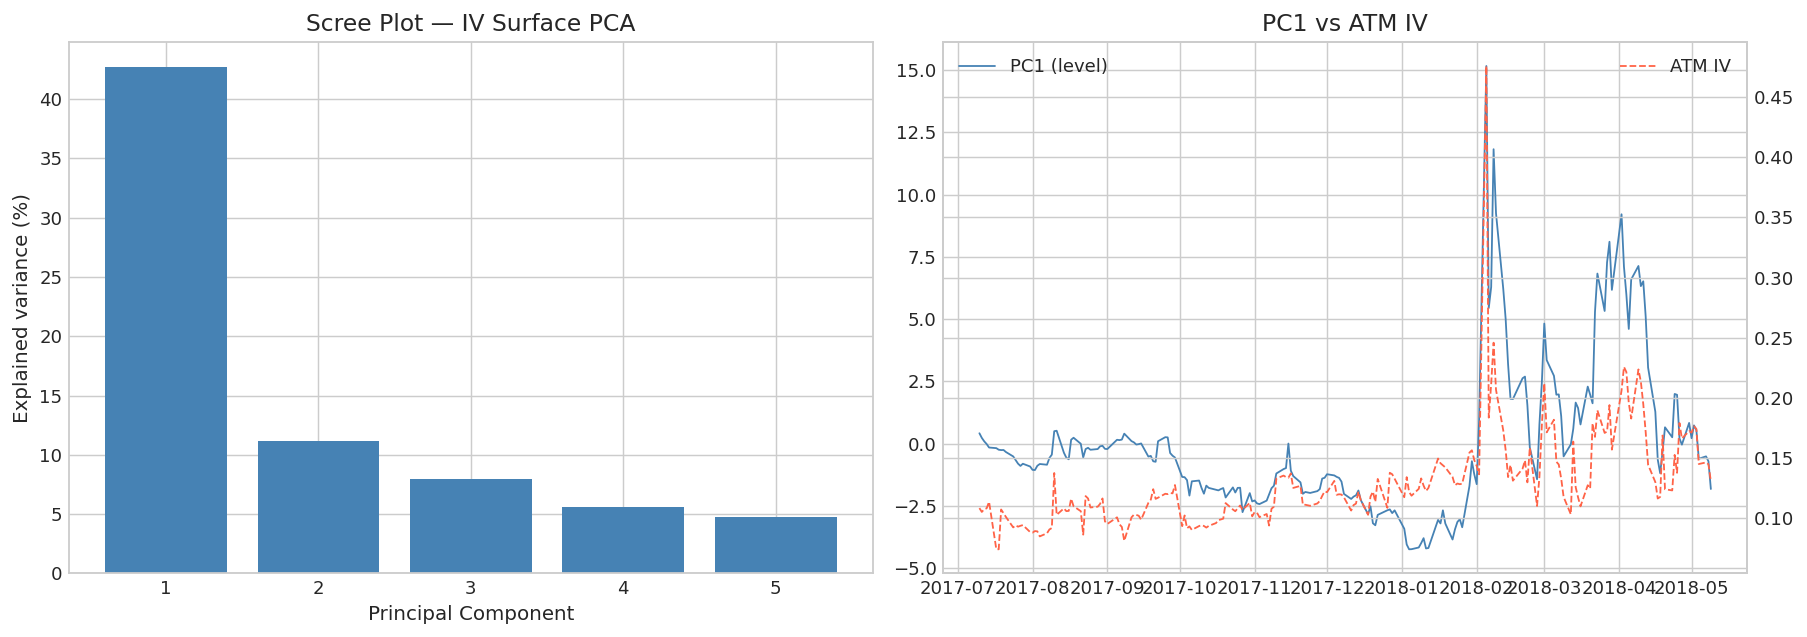

                            OLS Regression Results                            
Dep. Variable:             rv_forward   R-squared:                       0.137
Model:                            OLS   Adj. R-squared:                  0.125
Method:                 Least Squares   F-statistic:                     4.720
Date:                Thu, 11 Jun 2026   Prob (F-statistic):            0.00330
Time:                        11:20:17   Log-Likelihood:                 248.11
No. Observations:                 211   AIC:                            -488.2
Df Residuals:                     207   BIC:                            -474.8
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1166      0.020      5.896      0.0

In [136]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, 6), pca.explained_variance_ratio_ * 100, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained variance (%)')
axes[0].set_title('Scree Plot — IV Surface PCA')

# PC1 vs ATM IV
axes[1].plot(df_pca.index, df_pca['PC1_level'], color='steelblue', lw=1, label='PC1 (level)')
ax2 = axes[1].twinx()
ax2.plot(reg_overlap['atm_iv'].reindex(df_pca.index), color='tomato', lw=1, ls='--', label='ATM IV')
axes[1].set_title('PC1 vs ATM IV')
axes[1].legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Regression: PCA factors → RV forward
X_pca = sm.add_constant(df_pca[['PC1_level', 'PC2_skew', 'PC3_curv']])
y_pca = df_pca['rv_forward']
m_pca = sm.OLS(y_pca, X_pca).fit(cov_type='HAC', cov_kwds={'maxlags': 20})
print(m_pca.summary())

## 6 · Hybrid Models

We combine historical and option-implied information. 
The central question: does IV add predictive content beyond what past volatility already captures?

### 6.1 HAR-IV

$$\text{Var}^{\text{fwd}}_t = \beta_0 + \beta_d RV^d_t + \beta_w RV^w_t + \beta_m RV^m_t + \gamma IV^2_t + \varepsilon_t$$

**Estimation space: variance**, consistent with the HAR baseline of Section 2.2.
$IV^2_t$ enters as the variance-space counterpart of ATM IV, preserving dimensional
consistency across all regressors. The F-test on $\gamma = 0$ measures the marginal
predictive contribution of implied volatility beyond what past return history already captures.

**Forecast conversion.** As with HAR, the variance forecast is converted back to volatility
$\widehat{RV}^{\text{fwd}}_t = \sqrt{\max(\widehat{\text{Var}}^{\text{fwd}}_t, 0)}$ before entering
the OOS evaluation table.

In [ ]:
# =============================================================================
# HAR-IV - estimated in variance space (consistent with HAR baseline)
# =============================================================================

df_hybrid = pd.DataFrame({
    'rv_d': rv_d_var,
    'rv_w': rv_d_var.rolling(5).mean(),
    'rv_m': rv_d_var.rolling(21).mean(),
}, index=log_ret.index)
df_hybrid = df_hybrid.join(reg_overlap[['rv_forward', 'atm_iv']], how='inner').dropna()
df_hybrid['var_forward'] = df_hybrid['rv_forward'] ** 2
df_hybrid['iv_var']      = df_hybrid['atm_iv'] ** 2

X_hariv = sm.add_constant(df_hybrid[['rv_d', 'rv_w', 'rv_m', 'iv_var']])
m_hariv = sm.OLS(df_hybrid['var_forward'], X_hariv).fit(cov_type='HAC', cov_kwds={'maxlags': 21})

coef_table = pd.DataFrame({
    'coef'   : m_hariv.params,
    'std err': m_hariv.bse,
    't-stat' : m_hariv.tvalues,
    'p-value': m_hariv.pvalues
}).round(4)
print(coef_table)
print(f'\nR2 = {m_hariv.rsquared:.4f}  |  Adj R2 = {m_hariv.rsquared_adj:.4f}')

f_iv = m_hariv.f_test('iv_var = 0')
print(f'\nMarginal IV (F-test): F = {float(f_iv.fvalue):.2f}  p = {float(f_iv.pvalue):.4f}')
print(f'-> IV adds information beyond HAR: {float(f_iv.pvalue) < 0.05}')

# Forecast -> volatility space
df_hybrid['hariv_fitted_var'] = m_hariv.fittedvalues
df_hybrid['hariv_fitted_vol'] = np.sqrt(np.maximum(df_hybrid['hariv_fitted_var'], 0))

### 6.2 Encompassing Regression

$$RV^{\text{fwd}}_t = \alpha + \beta_1 \widehat{RV}^{\text{HAR}}_t + \beta_2 \widehat{RV}^{\text{IV}}_t + u_t$$

If both $\beta_1, \beta_2$ are significant: neither model encompasses the other.

In [ ]:
# =============================================================================
# Encompassing regression - variance space, consistent with HAR and HAR-IV
# =============================================================================

df_enc = pd.DataFrame({
    'rv_d': rv_d_var,
    'rv_w': rv_d_var.rolling(5).mean(),
    'rv_m': rv_d_var.rolling(21).mean(),
}).join(reg_overlap[['rv_forward', 'atm_iv']], how='inner').dropna()

df_enc['var_forward'] = df_enc['rv_forward'] ** 2
df_enc['iv_var']      = df_enc['atm_iv'] ** 2

X_har_enc = sm.add_constant(df_enc[['rv_d', 'rv_w', 'rv_m']])
m_har_enc = sm.OLS(df_enc['var_forward'], X_har_enc).fit(cov_type='HAC', cov_kwds={'maxlags': 21})
df_enc['har_fitted'] = m_har_enc.fittedvalues

X_iv_enc = sm.add_constant(df_enc[['iv_var']])
m_iv_enc = sm.OLS(df_enc['var_forward'], X_iv_enc).fit(cov_type='HAC', cov_kwds={'maxlags': 21})
df_enc['iv_fitted'] = m_iv_enc.fittedvalues

X_enc = sm.add_constant(df_enc[['har_fitted', 'iv_fitted']])
m_enc = sm.OLS(df_enc['var_forward'], X_enc).fit(cov_type='HAC', cov_kwds={'maxlags': 21})
print(m_enc.summary())
print()
print('beta_HAR =', round(m_enc.params['har_fitted'], 4),
      '  p =', round(m_enc.pvalues['har_fitted'], 4))
print('beta_IV  =', round(m_enc.params['iv_fitted'],  4),
      '  p =', round(m_enc.pvalues['iv_fitted'],  4))
print()
print('-> IV adds information beyond HAR:', m_enc.pvalues['iv_fitted']  < 0.05)
print('-> HAR adds information beyond IV:', m_enc.pvalues['har_fitted'] < 0.05)

### 6.3 HAR-PCA

$$\text{Var}^{\text{fwd}}_t = \beta_0 + \beta_d RV^d_t + \beta_w RV^w_t + \beta_m RV^m_t + \gamma_1 PC1_t + \gamma_2 PC2_t + \gamma_3 PC3_t + \varepsilon_t$$

**Estimation space: variance**, consistent with HAR and HAR-IV. The PCA factors are
dimensionless standardized scores (unit-free), so they enter the variance regression without
transformation. Joint F-test on $\gamma_1 = \gamma_2 = \gamma_3 = 0$ tests whether surface
shape information adds beyond the HAR variance components.

**Forecast conversion.** Variance forecast converted to volatility before OOS evaluation,
as in HAR and HAR-IV.

In [ ]:
# =============================================================================
# HAR-PCA - estimated in variance space (consistent with HAR baseline)
# =============================================================================

df_harpca = df_hybrid.join(df_pca[['PC1_level', 'PC2_skew', 'PC3_curv']], how='inner').dropna()

X_harpca = sm.add_constant(df_harpca[['rv_d', 'rv_w', 'rv_m', 'PC1_level', 'PC2_skew', 'PC3_curv']])
m_harpca = sm.OLS(df_harpca['var_forward'], X_harpca).fit(cov_type='HAC', cov_kwds={'maxlags': 21})

coef_table = pd.DataFrame({
    'coef'   : m_harpca.params,
    'std err': m_harpca.bse,
    't-stat' : m_harpca.tvalues,
    'p-value': m_harpca.pvalues
}).round(4)
print(coef_table)
print(f'\nR2 = {m_harpca.rsquared:.4f}  |  Adj R2 = {m_harpca.rsquared_adj:.4f}')

f_pca = m_harpca.f_test('(PC1_level = 0), (PC2_skew = 0), (PC3_curv = 0)')
print(f'\nJoint PCA factors beyond HAR: F = {float(f_pca.fvalue):.2f}  p = {float(f_pca.pvalue):.4f}')
print(f'-> Surface factors add information beyond HAR: {float(f_pca.pvalue) < 0.05}')

# Forecast -> volatility space
df_harpca['harpca_fitted_var'] = m_harpca.fittedvalues
df_harpca['harpca_fitted_vol'] = np.sqrt(np.maximum(df_harpca['harpca_fitted_var'], 0))

## 7 · Forecast Evaluation — Out-of-Sample

**Protocol**: expanding window -- at each test date $t$, models are re-estimated on all history
up to $t - 21$ (last 21 obs excluded to avoid `rv_forward` leakage). Train: 80% · Test: 20% (~39 obs).

**Evaluation space.**
All forecasts are evaluated against $RV^{\text{fwd}}_t$ in **volatility** space.
HAR-type models (HAR, HAR-IV, HAR-PCA) produce variance forecasts internally;
these are converted via $\sqrt{\max(\cdot, 0)}$ before entering the metrics below.

| Metric | Space | Reference |
|--------|-------|----------|
| RMSE | Volatility | Standard |
| MAE  | Volatility | Standard |
| QLIKE | Variance | Patton (2011) -- robust to noise in the RV proxy |

QLIKE is computed on variance: $\text{QLIKE}(\sigma^2, \hat{\sigma}^2) = \frac{\sigma^2}{\hat{\sigma}^2} - \ln\frac{\sigma^2}{\hat{\sigma}^2} - 1$. All forecasts are squared before computing QLIKE regardless of their estimation space.

DM test: Harvey-Leybourne-Newbold correction, $h = 21$ lags, squared-error loss in volatility space.

### 7.1 Expanding Window Forecasts

In [ ]:
# =============================================================================
# Expanding window setup
# All forecasts stored in `forecasts` are in VOLATILITY space.
# HAR-type models estimate in variance, convert output via sqrt.
# IV/PCA models estimate in volatility directly.
# =============================================================================

eval_df = reg_overlap.copy()
eval_df = eval_df.join(Vix_close.rename('vix'), how='left')
eval_df['vix_norm']       = eval_df['vix'] / 100
eval_df['vix_atm_spread'] = eval_df['vix_norm'] - eval_df['atm_iv']

# HAR variance components from pickle
eval_df['rv_d'] = rv_d_var.reindex(eval_df.index)
eval_df['rv_w'] = rv_d_var.rolling(5).mean().reindex(eval_df.index)
eval_df['rv_m'] = rv_d_var.rolling(21).mean().reindex(eval_df.index)
eval_df['var_forward'] = eval_df['rv_forward'] ** 2
eval_df['iv_var']      = eval_df['atm_iv'] ** 2

eval_df = eval_df.dropna(subset=['rv_forward', 'var_forward', 'atm_iv', 'rv_past',
                                   'vix_atm_spread', 'rv_d', 'rv_w', 'rv_m'])

n     = len(eval_df)
split = int(n * 0.80)
train = eval_df.iloc[:split]
test  = eval_df.iloc[split:]
eval_pca = eval_df.join(df_pca[['PC1_level', 'PC2_skew', 'PC3_curv']], how='left')

print(f'Train : {len(train)} obs  ({train.index[0].date()} -> {train.index[-1].date()})')
print(f'Test  : {len(test)}  obs  ({test.index[0].date()}  -> {test.index[-1].date()})')

# ── Vol-space expanding forecast (IV models, standalone PCA) ─────────────────
def expanding_forecast_vol(feature_cols, target_col='rv_forward', horizon=21):
    preds = []
    for i in range(split, n):
        df_train = eval_df.iloc[:i - horizon][feature_cols + [target_col]].dropna()
        df_test  = eval_df.iloc[[i]][feature_cols].dropna()
        if len(df_train) < len(feature_cols) + 2 or len(df_test) == 0:
            preds.append(np.nan); continue
        m   = sm.OLS(df_train[target_col], sm.add_constant(df_train[feature_cols])).fit()
        X_t = sm.add_constant(df_test, has_constant='add')
        preds.append(float(m.predict(X_t).iloc[0]))
    return np.array(preds)

# ── Variance-space expanding forecast - output converted to vol ───────────────
def expanding_forecast_var(feature_cols, target_col='var_forward', horizon=21):
    preds = []
    for i in range(split, n):
        df_train = eval_df.iloc[:i - horizon][feature_cols + [target_col]].dropna()
        df_test  = eval_df.iloc[[i]][feature_cols].dropna()
        if len(df_train) < len(feature_cols) + 2 or len(df_test) == 0:
            preds.append(np.nan); continue
        m      = sm.OLS(df_train[target_col], sm.add_constant(df_train[feature_cols])).fit()
        X_t    = sm.add_constant(df_test, has_constant='add')
        var_fc = float(m.predict(X_t).iloc[0])
        preds.append(np.sqrt(max(var_fc, 0)))   # variance -> volatility
    return np.array(preds)

def expanding_forecast_pca_only(pca_cols, target_col='rv_forward', horizon=21):
    preds = []
    for i in range(split, n):
        df_train = eval_pca.iloc[:i - horizon][pca_cols + [target_col]].dropna()
        df_test  = eval_pca.iloc[[i]][pca_cols].dropna()
        if len(df_train) < len(pca_cols) + 2 or len(df_test) == 0:
            preds.append(np.nan); continue
        m   = sm.OLS(df_train[target_col], sm.add_constant(df_train[pca_cols])).fit()
        X_t = sm.add_constant(df_test, has_constant='add')
        preds.append(float(m.predict(X_t).iloc[0]))
    return np.array(preds)

def expanding_forecast_harpca(har_cols, pca_cols, target_col='var_forward', horizon=21):
    all_cols = har_cols + pca_cols
    preds = []
    for i in range(split, n):
        df_train = eval_pca.iloc[:i - horizon][all_cols + [target_col]].dropna()
        df_test  = eval_pca.iloc[[i]][all_cols].dropna()
        if len(df_train) < len(all_cols) + 2 or len(df_test) == 0:
            preds.append(np.nan); continue
        m      = sm.OLS(df_train[target_col], sm.add_constant(df_train[all_cols])).fit()
        X_t    = sm.add_constant(df_test, has_constant='add')
        var_fc = float(m.predict(X_t).iloc[0])
        preds.append(np.sqrt(max(var_fc, 0)))
    return np.array(preds)

# ── Historical mean - volatility space ───────────────────────────────────────
forecasts = {}
forecasts['HistMean'] = np.array([
    eval_df.iloc[:split + i]['rv_forward'].mean() for i in range(len(test))
])

# ── HAR-type: estimated in variance, converted to vol ────────────────────────
forecasts['HAR']     = expanding_forecast_var(['rv_d', 'rv_w', 'rv_m'])
forecasts['HAR_IV']  = expanding_forecast_var(['rv_d', 'rv_w', 'rv_m', 'iv_var'])
forecasts['HAR_PCA'] = expanding_forecast_harpca(
    ['rv_d', 'rv_w', 'rv_m'], ['PC1_level', 'PC2_skew', 'PC3_curv'])

# ── IV/PCA: estimated and forecasted in vol ───────────────────────────────────
forecasts['ATM_IV']  = expanding_forecast_vol(['atm_iv'])
forecasts['IV_full'] = expanding_forecast_vol(['atm_iv', 'skew', 'convexity', 'vix_atm_spread'])
forecasts['PCA']     = expanding_forecast_pca_only(['PC1_level', 'PC2_skew', 'PC3_curv'])

# ── Evaluation target: volatility ────────────────────────────────────────────
y_test = test['rv_forward'].values   # VOLATILITY

print('\nExpanding window forecasts - all in volatility space.')
for name, fc in forecasts.items():
    print(f'  {name:<12}: {np.sum(~np.isnan(fc))} valid predictions')

### 7.2 Forecast Comparison Table

In [ ]:
from scipy.stats import t as t_dist

# =============================================================================
# Loss functions
# =============================================================================

def dm_test(y_vol, f1_vol, f2_vol, h=21):
    e1, e2 = y_vol - f1_vol, y_vol - f2_vol
    d = e1**2 - e2**2
    T = len(d)
    d_bar  = np.mean(d)
    gamma0 = np.var(d, ddof=0)
    gammas = [np.cov(d[j:], d[:-j], ddof=0)[0, 1] for j in range(1, h)]
    var_d  = (gamma0 + 2 * sum((1 - j/h) * gammas[j-1] for j in range(1, h))) / T
    dm_stat = d_bar / np.sqrt(var_d) * np.sqrt((T + 1 - 2*h + h*(h-1)/T) / T)
    return dm_stat, 2 * (1 - t_dist.cdf(abs(dm_stat), df=T-1))

def rmse(y, yhat):  return np.sqrt(np.mean((y - yhat)**2))
def mae(y, yhat):   return np.mean(np.abs(y - yhat))

def qlike(y_var, yhat_var):
    eps = 1e-10
    y_var    = np.maximum(y_var, eps)
    yhat_var = np.maximum(yhat_var, eps)
    return np.mean(y_var / yhat_var - np.log(y_var / yhat_var) - 1)

def stars(p):
    return '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''

# =============================================================================
# Evaluation - y_test and all forecasts in VOLATILITY space
# QLIKE: both y and yhat squared to enter variance space
# =============================================================================

model_names = ['HistMean', 'HAR', 'EGARCH', 'ATM_IV', 'IV_full', 'HAR_IV', 'PCA', 'HAR_PCA']

egarch_vol_test     = egarch_vol.reindex(test.index).values
forecasts['EGARCH'] = egarch_vol_test   # already annualized vol

y_vol = np.asarray(y_test)    # volatility
y_var = y_vol ** 2            # variance for QLIKE

har_fc_vol = np.asarray(forecasts['HAR'])
rows = []
har_rmse = har_mae = har_qlk = None

for name in model_names:
    fc_vol = forecasts.get(name)
    if fc_vol is None:
        rows.append({'Model': name, 'OOS RMSE': '-', 'OOS MAE': '-',
                     'OOS QLIKE': '-', '%D QLIKE': '-', 'DM vs HAR': '-'})
        continue
    fc_vol = np.asarray(fc_vol)
    n_eval = min(len(fc_vol), len(y_vol))
    yv, yq, fcv = y_vol[:n_eval], y_var[:n_eval], fc_vol[:n_eval]
    mask = ~np.isnan(yv) & ~np.isnan(fcv)
    yv, yq, fcv = yv[mask], yq[mask], fcv[mask]

    r = rmse(yv, fcv)
    m = mae(yv, fcv)
    q = qlike(yq, fcv**2)   # square vol forecast -> variance space

    if name == 'HAR':
        har_rmse, har_mae, har_qlk = r, m, q
        dm_str, gain = '-', 0.0
    else:
        har_eval = har_fc_vol[:n_eval][mask]
        dm_stat, dm_p = dm_test(yv, har_eval, fcv, h=21)
        dm_str = f'{dm_stat:+.2f}{stars(dm_p)} {"up" if dm_stat > 0 else "dn"}'
        gain   = 100 * (har_qlk - q) / har_qlk

    rows.append({'Model': name, 'OOS RMSE': f'{r:.4f}', 'OOS MAE': f'{m:.4f}',
                 'OOS QLIKE': f'{q:.4f}', '%D QLIKE': f'{gain:+.1f}%', 'DM vs HAR': dm_str})

df_results = pd.DataFrame(rows).set_index('Model')

print('=' * 80)
print('OUT-OF-SAMPLE FORECAST COMPARISON')
print('RMSE, MAE: volatility  |  QLIKE: variance (Patton 2011)')
print('=' * 80)
print(f'Test period : {test.index[0].date()} -> {test.index[-1].date()}  |  N = {len(y_test)}')
print('DM: HLN-corrected, h=21  |  up = challenger better  |  dn = HAR better')
print('\n' + '=' * 80)
print(df_results.to_string())
print('=' * 80)
best_rmse = df_results['OOS RMSE'].replace('-', np.nan).astype(float).idxmin()
best_qlk  = df_results['OOS QLIKE'].replace('-', np.nan).astype(float).idxmin()
print(f'\nBest RMSE  : {best_rmse}')
print(f'Best QLIKE : {best_qlk}')

### 7.3 Complexity vs OOS Robustness

Tests the bias-variance trade-off: higher in-sample $R^2$ should not mechanically imply better OOS performance, especially in small samples.

In [ ]:
# Reconstruire metrics_oos depuis df_results
metrics_oos = {}
for name in df_results.index:
    try:
        metrics_oos[name] = (
            float(df_results.loc[name, 'OOS RMSE']),
            float(df_results.loc[name, 'OOS MAE']),
            float(df_results.loc[name, 'OOS QLIKE'])
        )
    except:
        pass

# Complexité vs robustesse OOS — tableau synthétique
complexity = {
    'HistMean' : 0,
    'HAR'      : 3,
    'ATM_IV'   : 1,
    'IV_full'  : 4,
    'PCA'      : 3,
    'HAR_IV'   : 4,
    'HAR_PCA'  : 6,
}

print(f'{"Model":<12}  {"Params":>8}  {"OOS RMSE":>10}  {"OOS QLIKE":>10}  {"IS R²":>8}')
print('─' * 56)

is_r2 = {
    'HistMean' : 0.000,
    'HAR'      : 0.060,
    'ATM_IV'   : 0.167,
    'IV_full'  : 0.240,
    'PCA'      : 0.137,
    'HAR_IV'   : 0.071,
    'HAR_PCA'  : 0.214,
}

for name in complexity:
    if name not in metrics_oos:
        continue
    r, m, q = metrics_oos[name]
    print(f'{name:<12}  {complexity[name]:>8}  {float(r):>10.4f}  {float(q):>10.4f}  {is_r2[name]:>8.3f}')

Model           Params    OOS RMSE   OOS QLIKE     IS R²
────────────────────────────────────────────────────────
HAR                  3      0.0573      0.3762     0.060
ATM_IV               1      0.0649      0.4670     0.167
PCA                  3      0.0940    129.0619     0.137
HAR_IV               4      0.0971      0.6758     0.071
HAR_PCA              6      0.1654     93.2665     0.214


### 7.4 Visual Diagnostics

In [ ]:
# 1. Vérification visuelle
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

axes[0].plot(test.index, y_test, label='Realized vol', color='black', lw=1.5)
axes[0].plot(test.index, forecasts['HAR'],   label='HAR',    color='steelblue', lw=1)
axes[0].plot(test.index, forecasts['ATM_IV'],label='ATM_IV', color='tomato',    lw=1, ls='--')
axes[0].set_title('Realized vs Forecasts — Test Set')
axes[0].legend()

axes[1].plot(test.index, y_test,              label='Realized vol', color='black', lw=1.5)
axes[1].plot(test.index, forecasts['PCA'],    label='PCA',      color='purple',    lw=1)
axes[1].plot(test.index, forecasts['HAR_PCA'],label='HAR_PCA',  color='orange',    lw=1, ls='--')
axes[1].set_title('Realized vs PCA Forecasts — Test Set')
axes[1].legend()

plt.tight_layout()
plt.show()

# 2. Stabilité des facteurs PCA entre train et test
pca_train = df_pca.reindex(train.index).dropna()
pca_test  = df_pca.reindex(test.index).dropna()

print('PCA factors — train vs test')
print(f'{"Factor":<12}  {"Train mean":>12}  {"Test mean":>12}  {"Train std":>12}  {"Test std":>12}')
print('─' * 64)
for col in ['PC1_level', 'PC2_skew', 'PC3_curv']:
    print(f'{col:<12}  {pca_train[col].mean():>12.3f}  {pca_test[col].mean():>12.3f}  '
          f'{pca_train[col].std():>12.3f}  {pca_test[col].std():>12.3f}')

# 3. Distribution shift entre train et test
print('\nFeature distribution shift — train vs test')
print(f'{"Feature":<16}  {"Train mean":>12}  {"Test mean":>12}  {"Ratio":>8}')
print('─' * 54)
for col in ['atm_iv', 'rv_d', 'rv_w', 'rv_m']:
    tm = train[col].mean()
    te = test[col].mean()
    print(f'{col:<16}  {tm:>12.4f}  {te:>12.4f}  {te/tm:>8.2f}x')

## 7B · Robustness — Sensitivity to the February 2018 Volatility Event

The test set coincides with the normalization phase following the Volmageddon spike (Feb 5, 2018).
We assess whether OOS results are driven by this single extreme event by re-estimating the HAR
model after excluding the nine trading days around the spike.

The HAR robustness loop follows the same convention as Section 7: estimated in **variance** space,
forecasts converted to **volatility** before computing RMSE and QLIKE.

> This is a **sensitivity analysis**, not a model fix.
A post-spike dummy would introduce look-ahead bias in a real-time forecasting exercise.

In [ ]:
# =============================================================================
# Robustness to the February 2018 volatility event
# HAR re-estimated in variance space - forecasts converted to volatility
# =============================================================================

volma_window = pd.date_range('2018-01-31', '2018-02-12', freq='B')
df_no_volma  = eval_df[~eval_df.index.isin(volma_window)]

n_r     = len(df_no_volma)
split_r = int(n_r * 0.80)
train_r = df_no_volma.iloc[:split_r]
test_r  = df_no_volma.iloc[split_r:]
y_test_r = test_r['rv_forward'].values   # volatility

print(f'Excl. Volmageddon window: {len(eval_df) - n_r} obs removed')
print(f'Train: {len(train_r)}  Test: {len(test_r)}')

results_rob = {}

for label, df_, y_ in [
    ('Baseline',     eval_df,     y_test),
    ('Excl. window', df_no_volma, y_test_r),
]:
    n_  = len(df_)
    sp_ = int(n_ * 0.80)
    fc_ = []
    for i in range(sp_, n_):
        df_tr = df_.iloc[:i - 21][['rv_d', 'rv_w', 'rv_m', 'var_forward']].dropna()
        df_te = df_.iloc[[i]][['rv_d', 'rv_w', 'rv_m']].dropna()
        if len(df_tr) < 5 or len(df_te) == 0:
            fc_.append(np.nan); continue
        m      = sm.OLS(df_tr['var_forward'],
                        sm.add_constant(df_tr[['rv_d', 'rv_w', 'rv_m']])).fit()
        var_fc = float(m.predict(sm.add_constant(df_te, has_constant='add')).iloc[0])
        fc_.append(np.sqrt(max(var_fc, 0)))   # variance -> volatility
    fc_    = np.array(fc_)
    mask_  = ~np.isnan(fc_)
    y_eval = y_[:len(fc_)][mask_]
    f_eval = fc_[mask_]
    results_rob[label] = {
        'RMSE' : rmse(y_eval, f_eval),
        'QLIKE': qlike(y_eval**2, f_eval**2),
        'Corr' : float(pd.Series(y_eval).corr(pd.Series(f_eval)))
    }

print('\n' + '=' * 60)
print('HAR ROBUSTNESS CHECK  (var-space estimation, vol evaluation)')
print('=' * 60)
print(f'{"Specification":<20}  {"RMSE":>8}  {"QLIKE":>8}  {"Corr":>8}')
print('-' * 50)
for label, res in results_rob.items():
    print(f'{label:<20}  {res["RMSE"]:>8.4f}  {res["QLIKE"]:>8.4f}  {res["Corr"]:>8.3f}')
print('=' * 60)
print('If RMSE/QLIKE remain similar: results are robust to the Volmageddon event.')
print('If results change substantially: a single event drives the conclusions.')

In [ ]:
print('Baseline test set:')
print(f'  dates : {eval_df.iloc[split:].index[0].date()} → {eval_df.iloc[split:].index[-1].date()}')
print(f'  rv_forward mean : {eval_df.iloc[split:]["rv_forward"].mean():.4f}')

print('\nExcl. window test set:')
n_r  = len(df_no_volma)
sp_r = int(n_r * 0.80)
print(f'  dates : {df_no_volma.iloc[sp_r:].index[0].date()} → {df_no_volma.iloc[sp_r:].index[-1].date()}')
print(f'  rv_forward mean : {df_no_volma.iloc[sp_r:]["rv_forward"].mean():.4f}')

Baseline test set:
  dates : 2018-03-15 → 2018-05-09
  rv_forward mean : 0.1404

Excl. window test set:
  dates : 2018-03-19 → 2018-05-09
  rv_forward mean : 0.1353


In [ ]:
# HAR expanding forecast - excl. Volmageddon window
# Estimated in variance space, converted to volatility

fc_no_volma = []

for i in range(sp_r, n_r):
    df_tr = df_no_volma.iloc[:i - 21][['rv_d', 'rv_w', 'rv_m', 'var_forward']].dropna()
    df_te = df_no_volma.iloc[[i]][['rv_d', 'rv_w', 'rv_m']].dropna()
    if len(df_tr) < 5 or len(df_te) == 0:
        fc_no_volma.append(np.nan); continue
    m      = sm.OLS(df_tr['var_forward'],
                    sm.add_constant(df_tr[['rv_d', 'rv_w', 'rv_m']])).fit()
    var_fc = float(m.predict(sm.add_constant(df_te, has_constant='add')).iloc[0])
    fc_no_volma.append(np.sqrt(max(var_fc, 0)))

fc_no_volma = np.array(fc_no_volma)

In [ ]:
# Directional accuracy and bias - all series in volatility space

for label, fc_, y_ in [
    ('With Volmageddon',    forecasts['HAR'],       y_test),
    ('Without Volmageddon', np.array(fc_no_volma),  y_test_r),
]:
    fc_  = np.array(fc_)
    mask = ~np.isnan(fc_)
    y_m  = y_[:len(fc_)][mask]
    f_m  = fc_[mask]

    bias        = np.mean(f_m - y_m)
    dy          = np.diff(y_m)
    df_         = np.diff(f_m)
    directional = np.mean(np.sign(dy) == np.sign(df_))

    print(f'{label}')
    print(f'  Mean bias (vol)      : {bias:+.4f}  (+ = over-estimation)')
    print(f'  Directional accuracy : {directional:.2%}  (correct sign of change)')

## 8 · Trading Application — VRP Signal

$$\text{Signal}_t = \widehat{RV}^{\text{fwd}}_t - IV_t$$

Long vol if Signal $> 0$ (model forecasts more volatility than the market prices in),
short vol if Signal $< 0$ (options expensive relative to the forecast).

PnL proxy (variance swap approximation, volatility space):

$$\text{PnL}_t = \text{Position}_t \times (RV^{\text{fwd}}_t - IV_t)$$

**Space consistency**: $\widehat{RV}^{\text{fwd}}_t$ and $IV_t$ are both in annualized
volatility -- the signal is dimensionally clean.
Strategy built exclusively from OOS forecasts (best model from Section 7).
Results reported with and without the Feb 5, 2018 Volmageddon event.

In [ ]:
# Best model from Section 7 - update based on your results
best_model = 'HAR'
fc_best    = forecasts[best_model]   # volatility space (sqrt already applied for HAR-type)

# ATM IV and realized vol on test set - both in volatility space
iv_test = test['atm_iv'].values[:len(fc_best)]
y_test_ = y_test[:len(fc_best)]      # rv_forward, volatility

# Signal - vol minus vol, dimensionally consistent
signal   = fc_best - iv_test         # >0 long vol, <0 short vol
position = np.sign(signal)

# PnL - variance swap approximation
pnl     = position * (y_test_ - iv_test)
cum_pnl = np.cumsum(pnl)

n_trades    = len(pnl)
hit_ratio   = np.mean(pnl > 0)
sharpe      = pnl.mean() / pnl.std() * np.sqrt(252 / 21)
rolling_max = np.maximum.accumulate(cum_pnl)
max_dd      = (cum_pnl - rolling_max).min()

print('=' * 50)
print(f'Trading Strategy -- {best_model}')
print('=' * 50)
print(f'N trades      : {n_trades}')
print(f'Hit ratio     : {hit_ratio:.2%}')
print(f'Sharpe (ann.) : {sharpe:.2f}')
print(f'Max drawdown  : {max_dd:.4f}')
print(f'Total PnL     : {cum_pnl[-1]:.4f}')

test_dates  = test.index[:len(fc_best)]
no_vol_mask = test_dates != pd.Timestamp('2018-02-05')
if no_vol_mask.sum() < len(no_vol_mask):
    pnl_robust = pnl[no_vol_mask]
    sharpe_r   = pnl_robust.mean() / pnl_robust.std() * np.sqrt(252 / 21)
    print(f'\n--- Excl. Volmageddon ---')
    print(f'Hit ratio     : {np.mean(pnl_robust > 0):.2%}')
    print(f'Sharpe (ann.) : {sharpe_r:.2f}')

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Panel A: cumulative PnL
axes[0].plot(test_dates, cum_pnl, color='steelblue', lw=1.5, label='Cumulative PnL')
axes[0].axhline(0, color='black', lw=0.8, ls='--')
axes[0].fill_between(test_dates, cum_pnl, 0,
                      where=cum_pnl >= 0, alpha=0.2, color='steelblue')
axes[0].fill_between(test_dates, cum_pnl, 0,
                      where=cum_pnl < 0,  alpha=0.2, color='tomato')
axes[0].set_title(f'Cumulative PnL — {best_model} (Sharpe = {sharpe:.2f})')
axes[0].set_ylabel('Cumulative PnL')
axes[0].legend()

# Panel B: signal and RV vs IV
axes[1].plot(test_dates, y_test_, color='black',    lw=1,   label='Realized Vol')
axes[1].plot(test_dates, iv_test,  color='tomato',  lw=1,   ls='--', label='ATM IV')
axes[1].plot(test_dates, fc_best,  color='steelblue', lw=1, ls=':', label=f'{best_model} forecast')
axes[1].set_title('RV vs IV vs Forecast')
axes[1].set_ylabel('Annualized volatility (all series in vol space)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# Consistency check - verify all forecasts are in volatility space
# =============================================================================

print('y_test (rv_forward, vol)     :', y_test[:3].round(4))
print('HAR forecast (sqrt applied)  :', forecasts['HAR'][:3].round(4))
print('ATM_IV forecast (vol direct) :', forecasts['ATM_IV'][:3].round(4))
print()
har_var_fitted = har_model.fittedvalues.values[:3]
har_vol_fitted = np.sqrt(np.maximum(har_var_fitted, 0))
print('HAR in-sample: var fitted     :', har_var_fitted.round(6))
print('HAR in-sample: vol converted  :', har_vol_fitted.round(4))
print('rv_forward (same dates)       :', df_har['rv_forward'].values[:3].round(4))